In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

batch_size = 128
epochs = 10
lr = 1e-3
mc_samples = 20
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)

In [17]:
class CNN(nn.Module):
    def __init__(self, dropout_p=0.3, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(p=dropout_p)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.dropout(x)

        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout(x)

        x = self.pool(F.relu(self.conv3(x)))
        x = self.dropout(x)

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [18]:
transform_cifar = transforms.Compose([
    transforms.ToTensor()
])

transform_mnist = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.expand(3, -1, -1))
])

train_id = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_cifar)
test_id = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_cifar)
test_ood = datasets.MNIST(root='./data', train=False, download=True, transform=transform_mnist)

train_id_loader = DataLoader(train_id, batch_size=batch_size, shuffle=True)
test_id_loader = DataLoader(test_id, batch_size=batch_size, shuffle=False)
test_ood_loader = DataLoader(test_ood, batch_size=batch_size, shuffle=False)

In [19]:
def train(model, train_loader, epochs, lr):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_function = nn.CrossEntropyLoss()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        correct_samples = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = loss_function(logits, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct_samples += (preds == y).sum().item()

        print(f'Epoch {epoch}; Train loss {total_loss / len(train_loader)}; Accuracy {correct_samples / len(train_loader) * 100}')

In [20]:
def compute_ood_metrics(id_scores, ood_scores):
    y_true = np.concatenate([
        np.zeros_like(id_scores),
        np.ones_like(ood_scores)
    ])
    scores = np.concatenate([id_scores, ood_scores])
    auroc = roc_auc_score(y_true, scores)
    aupr = average_precision_score(y_true, scores)
    fpr, tpr, _ = roc_curve(y_true, scores)
    target_tpr = 0.95
    idxs = np.where(tpr >= target_tpr)[0]
    if len(idxs) > 0:
        fpr95 = fpr[idxs[0]]
    else:
        fpr95 = 1.0

    print(f'AUROC {auroc}')
    print(f'AUPR {aupr}')
    print(f'FPR@95%TPR {fpr95}')

    return auroc, aupr, fpr95

In [21]:
def get_softmax_ood_scores(model, id_loader, ood_loader):
    model.to(device)
    model.eval()
    id_scores = []
    ood_scores = []

    with torch.no_grad():
        for x, _ in id_loader:
            x = x.to(device)
            logits = model(x)
            probs = F.softmax(logits, dim=1)
            max_probs, _ = probs.max(dim=1)
            scores = 1.0 - max_probs

            id_scores.append(scores.cpu().numpy())

    with torch.no_grad():
        for x, _ in ood_loader:
            x = x.to(device)
            logits = model(x)
            probs = F.softmax(logits, dim=1)
            max_probs, _ = probs.max(dim=1)
            scores = 1.0 - max_probs
            ood_scores.append(scores.cpu().numpy())
    id_scores = np.concatenate(id_scores)
    ood_scores = np.concatenate(ood_scores)

    return id_scores, ood_scores


def get_mcd_ood_entropy(model, x, T=20):
    model.to(device)
    model.train()

    with torch.no_grad():
        probs_T = []
        for _ in range(T):
            logits = model(x)
            probs = F.softmax(logits, dim=1)
            probs_T.append(probs.unsqueeze(0))
        probs_T = torch.cat(probs_T, dim=0)
    p_mean = probs_T.mean(dim=0)
    eps = 1e-8
    entropy = -torch.sum(p_mean * torch.log(p_mean + eps), dim=1)

    return entropy


def get_mcd_ood_scores(model, id_loader, ood_loader, T=20):
    model.to(device)
    id_scores = []
    ood_scores = []

    for x, _ in id_loader:
        x = x.to(device)
        entropy = get_mcd_ood_entropy(model, x, T=T)
        id_scores.append(entropy.cpu().numpy())

    for x, _ in ood_loader:
        x = x.to(device)
        entropy = get_mcd_ood_entropy(model, x, T=T)
        ood_scores.append(entropy.cpu().numpy())

    id_scores = np.concatenate(id_scores)
    ood_scores = np.concatenate(ood_scores)

    return id_scores, ood_scores

In [22]:
def _penultimate_features(model, x):
    x = model.pool(F.relu(model.conv1(x)))
    x = model.dropout(x)
    x = model.pool(F.relu(model.conv2(x)))
    x = model.dropout(x)
    x = model.pool(F.relu(model.conv3(x)))
    x = model.dropout(x)
    x = x.view(x.size(0), -1)
    feats = F.relu(model.fc1(x))
    return feats

@torch.no_grad()
def compute_react_clip_value(model, id_loader, percentile=90.0, max_batches=None):
    model.to(device)
    model.eval()

    acts = []
    for b, (x, _) in enumerate(id_loader):
        if max_batches is not None and b >= max_batches:
            break
        x = x.to(device)
        feats = _penultimate_features(model, x).detach().cpu().numpy()
        acts.append(feats.reshape(-1)) 
    acts = np.concatenate(acts, axis=0)
    clip_value = float(np.percentile(acts, percentile))
    return clip_value

@torch.no_grad()
def get_react_ood_scores(model, id_loader, ood_loader, clip_value, score_type="msp"):
    model.to(device)
    model.eval()

    def _score_from_logits(logits):
        if score_type == "msp":
            probs = F.softmax(logits, dim=1)
            max_probs, _ = probs.max(dim=1)
            return 1.0 - max_probs
        elif score_type == "energy":
            return -torch.logsumexp(logits, dim=1)
        else:
            raise ValueError("score_type must be 'msp' or 'energy'")

    id_scores, ood_scores = [], []

    for x, _ in id_loader:
        x = x.to(device)
        feats = _penultimate_features(model, x)
        feats = torch.clamp(feats, max=clip_value)
        logits = model.fc2(feats)
        scores = _score_from_logits(logits)
        id_scores.append(scores.cpu().numpy())

    for x, _ in ood_loader:
        x = x.to(device)
        feats = _penultimate_features(model, x)
        feats = torch.clamp(feats, max=clip_value)
        logits = model.fc2(feats)
        scores = _score_from_logits(logits)
        ood_scores.append(scores.cpu().numpy())

    return np.concatenate(id_scores), np.concatenate(ood_scores)


In [23]:
model = CNN(dropout_p=0.3, num_classes=10)
train(model, train_id_loader, epochs=epochs, lr=lr)

Epoch 1; Train loss 1.7093703880944215; Accuracy 4750.383631713556
Epoch 2; Train loss 1.3515172184580733; Accuracy 6509.20716112532
Epoch 3; Train loss 1.2133603810959155; Accuracy 7266.496163682865
Epoch 4; Train loss 1.1161006222600522; Accuracy 7686.95652173913
Epoch 5; Train loss 1.0377757351111878; Accuracy 8082.352941176471
Epoch 6; Train loss 0.9869607876023978; Accuracy 8315.856777493605
Epoch 7; Train loss 0.9463881917316895; Accuracy 8500.511508951406
Epoch 8; Train loss 0.9021060236579622; Accuracy 8729.15601023018
Epoch 9; Train loss 0.8690294059341216; Accuracy 8866.751918158567
Epoch 10; Train loss 0.843890978704633; Accuracy 8976.470588235294


In [24]:
softmax_id_scores, softmax_ood_scores = get_softmax_ood_scores(model, test_id_loader, test_ood_loader)

In [25]:
auroc, aupr, fpr95 = compute_ood_metrics(softmax_id_scores, softmax_ood_scores)

AUROC 0.633756595
AUPR 0.5624677300582986
FPR@95%TPR 0.7316


In [26]:
mcd_id_scores, mcd_ood_scores = get_mcd_ood_scores(model, test_id_loader, test_ood_loader)

In [27]:
mcd_auroc, mcd_aupr, mcd_fpr95 = compute_ood_metrics(mcd_id_scores, mcd_ood_scores)

AUROC 0.7381110450000001
AUPR 0.6358088271053212
FPR@95%TPR 0.5738


In [28]:
react_percentile = 90.0

clip_value = compute_react_clip_value(model, train_id_loader, percentile=react_percentile)
print(f"Порог ReAct (перцентиль p{react_percentile:.0f}) = {clip_value:.6f}")

react_id_scores, react_ood_scores = get_react_ood_scores(
    model, test_id_loader, test_ood_loader, clip_value=clip_value, score_type="msp"
)
react_auroc, react_aupr, react_fpr95 = compute_ood_metrics(react_id_scores, react_ood_scores)
reactE_id_scores, reactE_ood_scores = get_react_ood_scores(
    model, test_id_loader, test_ood_loader, clip_value=clip_value, score_type="energy"
)
reactE_auroc, reactE_aupr, reactE_fpr95 = compute_ood_metrics(reactE_id_scores, reactE_ood_scores)

results = {
    "Softmax (MSP)": (auroc, aupr, fpr95),
    "MC Dropout (энтропия)": (mcd_auroc, mcd_aupr, mcd_fpr95),
    "ReAct + MSP": (react_auroc, react_aupr, react_fpr95),
    "ReAct + Energy": (reactE_auroc, reactE_aupr, reactE_fpr95),
}

print("\nИтоги (AUROC/AUPR: больше — лучше; FPR@95: меньше — лучше)")
for k, (r_auroc, r_aupr, r_fpr95) in results.items():
    print(f"{k:20s} | AUROC={r_auroc:.4f}  AUPR={r_aupr:.4f}  FPR95={r_fpr95:.4f}")


Порог ReAct (перцентиль p90) = 1.054046
AUROC 0.846440415
AUPR 0.8093378640011181
FPR@95%TPR 0.4423
AUROC 0.9266909
AUPR 0.8788843707422027
FPR@95%TPR 0.2157

Итоги (AUROC/AUPR: больше — лучше; FPR@95: меньше — лучше)
Softmax (MSP)        | AUROC=0.6338  AUPR=0.5625  FPR95=0.7316
MC Dropout (энтропия) | AUROC=0.7381  AUPR=0.6358  FPR95=0.5738
ReAct + MSP          | AUROC=0.8464  AUPR=0.8093  FPR95=0.4423
ReAct + Energy       | AUROC=0.9267  AUPR=0.8789  FPR95=0.2157


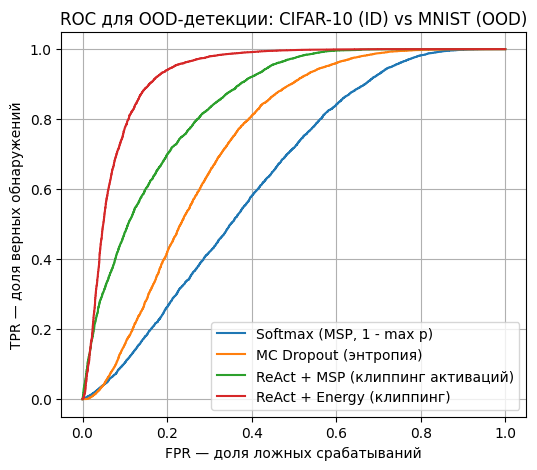

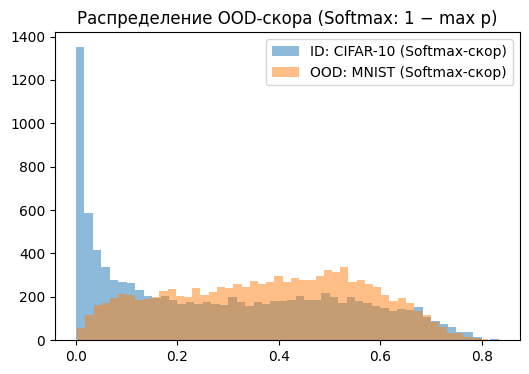

In [29]:
import matplotlib.pyplot as plt

def plot_roc(id_scores, ood_scores, label):
    y_true = np.concatenate([np.zeros_like(id_scores), np.ones_like(ood_scores)])
    scores = np.concatenate([id_scores, ood_scores])
    fpr, tpr, _ = roc_curve(y_true, scores)
    plt.plot(fpr, tpr, label=label)

plt.figure(figsize=(6, 5))
plot_roc(softmax_id_scores, softmax_ood_scores, "Softmax (MSP, 1 - max p)")
plot_roc(mcd_id_scores, mcd_ood_scores, "MC Dropout (энтропия)")
plot_roc(react_id_scores, react_ood_scores, "ReAct + MSP (клиппинг активаций)")
plot_roc(reactE_id_scores, reactE_ood_scores, "ReAct + Energy (клиппинг)")
plt.xlabel("FPR — доля ложных срабатываний")
plt.ylabel("TPR — доля верных обнаружений")
plt.title("ROC для OOD-детекции: CIFAR-10 (ID) vs MNIST (OOD)")
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(6, 4))
plt.hist(softmax_id_scores, bins=50, alpha=0.5, label="ID: CIFAR-10 (Softmax-скор)")
plt.hist(softmax_ood_scores, bins=50, alpha=0.5, label="OOD: MNIST (Softmax-скор)")
plt.title("Распределение OOD-скора (Softmax: 1 − max p)")
plt.legend()
plt.show()
